<a href="https://colab.research.google.com/github/Mariam-Elbishbeashy/HeadlineGeneration-NLP/blob/main/headlineGenerationNLP_dataset_analysis_charts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Headline Generation Dataset Analysis Notebook

This notebook is for **analysis and charts only**.  
It does not repeat the full preprocessing pipeline.

The goal is to show the parts that actually matter for a headline generation project:

1. Dataset quality before vs after preprocessing
2. Duplicate and leakage analysis
3. Transformer token length analysis
4. Semantic similarity between article and headline
5. Headline n-gram patterns
6. Named entity analysis in headlines
7. Final dashboard summary

## 1. Install and Import Libraries

Run the installation cell once in Colab.  
After the packages are installed, you can set `INSTALL_PACKAGES = False`.

In [1]:
INSTALL_PACKAGES = True

if INSTALL_PACKAGES:
    !pip -q install transformers sentence-transformers spacy seaborn scikit-learn
    !python -m spacy download en_core_web_sm -q

print("Setup cell finished.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 28.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Setup cell finished.


In [2]:
import os
import re
import math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer

pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 2. Mount Google Drive and Set Paths

Edit these paths if your files are saved in a different folder.

Expected files:

- Raw dataset: `sampled_articles_dataset.pkl`
- Preprocessed full file: `news_headline_model_ready_full_wide.pkl`
- Preprocessed train/validation/test files

In [8]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Not running inside Colab, or Drive is already mounted/skipped.")

# Change these paths if needed
RAW_DATA_PATH = "/content/drive/MyDrive/headlineGenerationProjectNLP/sampled_articles_dataset.pkl"
PREPROCESSED_DIR = "/content/drive/MyDrive/headlineGenerationProjectNLP/news_headline_model_data"

# Local fallback for testing outside Colab
if not os.path.exists(RAW_DATA_PATH):
    RAW_DATA_PATH = "/mnt/data/sampled_articles_dataset.pkl"

if not os.path.exists(PREPROCESSED_DIR):
    PREPROCESSED_DIR = "/mnt/data/news_headline_model_data"

FULL_WIDE_PATH = os.path.join(PREPROCESSED_DIR, "news_headline_model_ready_full_wide.pkl")
TRAIN_WIDE_PATH = os.path.join(PREPROCESSED_DIR, "news_headline_train_wide.csv")
VAL_WIDE_PATH = os.path.join(PREPROCESSED_DIR, "news_headline_validation_wide.csv")
TEST_WIDE_PATH = os.path.join(PREPROCESSED_DIR, "news_headline_test_wide.csv")

print("Raw data path:", RAW_DATA_PATH)
print("Preprocessed directory:", PREPROCESSED_DIR)

Mounted at /content/drive
Raw data path: /content/drive/MyDrive/headlineGenerationProjectNLP/sampled_articles_dataset.pkl
Preprocessed directory: /content/drive/MyDrive/headlineGenerationProjectNLP/news_headline_model_data


## 3. Helper Functions

These small functions are used for length calculations, duplicate checks, charts, and safe loading.

In [4]:
def load_dataframe(path):
    path = str(path)
    if path.endswith(".csv"):
        return pd.read_csv(path)
    if path.endswith(".pkl") or path.endswith(".pickle"):
        return pd.read_pickle(path)
    if path.endswith(".parquet"):
        return pd.read_parquet(path)
    raise ValueError("Unsupported file type. Use csv, pkl, pickle, or parquet.")


def word_count(text):
    return len(str(text).split())


def clean_preview_text(text, max_chars=250):
    text = str(text).replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text[:max_chars]


def loose_key(text, max_chars=700):
    # This key is used only for analysis. It approximates near-duplicate detection.
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text[:max_chars]


def plot_hist(series, title, xlabel, bins=50):
    plt.figure(figsize=(10, 5))
    sns.histplot(series.dropna(), bins=bins, kde=False)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()


def plot_bar(series, title, xlabel, ylabel="Count", top_n=20):
    data = series.head(top_n).sort_values(ascending=True)
    plt.figure(figsize=(10, max(5, top_n * 0.35)))
    data.plot(kind="barh")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


def get_first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

## 4. Load Raw and Preprocessed Data

The raw file is used for **before preprocessing** analysis.  
The preprocessed full wide file is used for **after preprocessing** analysis.

If the preprocessed file is missing, run your preprocessing notebook first.

In [9]:
raw_df = load_dataframe(RAW_DATA_PATH)
print("Raw shape:", raw_df.shape)
display(raw_df.head(3))
print("Raw columns:", raw_df.columns.tolist())

if os.path.exists(FULL_WIDE_PATH):
    after_wide_df = load_dataframe(FULL_WIDE_PATH)
    print("After-preprocessing wide shape:", after_wide_df.shape)
    display(after_wide_df.head(3))
else:
    after_wide_df = None
    print("Preprocessed full wide file was not found.")
    print("Run the preprocessing notebook first, then rerun this analysis notebook.")

Raw shape: (49860, 12)


,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,-8290,-8290,2017-04-15 00:00:00,2017,4.0,15,Raymond Wong,It sure looks like the Galaxy S8's battery won't explode even if you stab it with a knife,"Samsung's Galaxy S8 blends beautiful design and performance effortlessly, but how much safer is its battery compared to the Galaxy Note 7? In January, Sams...",https://mashable.com/2017/04/15/samsung-galaxy-s8-battery-no-explosion-fire/,None,Mashable
1,-16035,-16035,2017-11-06,2017,11.0,6,Andrea K. Scott,Five Centuries of Drawings at the Morgan,"The almost unbearably excellent show “Drawn to Greatness: Master Drawings from the Thaw Collection” begins with a love story. In 1954, the dealer Eugene Tha...",https://www.newyorker.com/magazine/2017/11/06/five-centuries-of-drawings-at-the-morgan,magazine,New Yorker
2,8290,8290,2019-08-09,2019,8.0,9,"Justin Hill, Opinion Contributor",Retaliation tweets like Castro's to discourage political involvement must stop | TheHill,"This week, Rep. Joaquin CastroJoaquin CastroThe exhaustion of Democrats' anti-Trump delusions Juan Williams: Democrats finally hit Trump where it hurts Texa...",https://thehill.com/blogs/congress-blog/politics/456873-retaliation-tweets-like-castros-to-discourage-political,None,The Hill


Raw columns: ['idx', 'article_idx', 'date', 'year', 'month', 'day', 'author', 'title', 'article', 'url', 'section', 'publication']
After-preprocessing wide shape: (47596, 12)


,flan_t5_small_article,flan_t5_small_title,flan_t5_base_article,flan_t5_base_title,t5_small_article,t5_small_title,t5_base_article,t5_base_title,bart_base_article,bart_base_title,gpt2_article,gpt2_title
0,"summarize: Samsung's Galaxy S8 blends beautiful design and performance effortlessly, but how much safer is its battery compared to the Galaxy Note 7? In Jan...",It sure looks like the Galaxy S8's battery won't explode even if you stab it with a knife,"summarize: Samsung's Galaxy S8 blends beautiful design and performance effortlessly, but how much safer is its battery compared to the Galaxy Note 7? In Jan...",It sure looks like the Galaxy S8's battery won't explode even if you stab it with a knife,"summarize: Samsung's Galaxy S8 blends beautiful design and performance effortlessly, but how much safer is its battery compared to the Galaxy Note 7? In Jan...",It sure looks like the Galaxy S8's battery won't explode even if you stab it with a knife,"summarize: Samsung's Galaxy S8 blends beautiful design and performance effortlessly, but how much safer is its battery compared to the Galaxy Note 7? In Jan...",It sure looks like the Galaxy S8's battery won't explode even if you stab it with a knife,"summarize: Samsung's Galaxy S8 blends beautiful design and performance effortlessly, but how much safer is its battery compared to the Galaxy Note 7? In Jan...",It sure looks like the Galaxy S8's battery won't explode even if you stab it with a knife,"Article: Samsung's Galaxy S8 blends beautiful design and performance effortlessly, but how much safer is its battery compared to the Galaxy Note 7? In Janua...",It sure looks like the Galaxy S8's battery won't explode even if you stab it with a knife
1,"summarize: The almost unbearably excellent show ""Drawn to Greatness: Master Drawings from the Thaw Collection"" begins with a love story. In 1954, the dealer...",Five Centuries of Drawings at the Morgan,"summarize: The almost unbearably excellent show ""Drawn to Greatness: Master Drawings from the Thaw Collection"" begins with a love story. In 1954, the dealer...",Five Centuries of Drawings at the Morgan,"summarize: The almost unbearably excellent show ""Drawn to Greatness: Master Drawings from the Thaw Collection"" begins with a love story. In 1954, the dealer...",Five Centuries of Drawings at the Morgan,"summarize: The almost unbearably excellent show ""Drawn to Greatness: Master Drawings from the Thaw Collection"" begins with a love story. In 1954, the dealer...",Five Centuries of Drawings at the Morgan,"summarize: The almost unbearably excellent show ""Drawn to Greatness: Master Drawings from the Thaw Collection"" begins with a love story. In 1954, the dealer...",Five Centuries of Drawings at the Morgan,"Article: The almost unbearably excellent show ""Drawn to Greatness: Master Drawings from the Thaw Collection"" begins with a love story. In 1954, the dealer E...",Five Centuries of Drawings at the Morgan
2,"summarize: This week, Rep. Joaquin CastroJoaquin CastroThe exhaustion of Democrats' anti-Trump delusions Juan Williams: Democrats finally hit Trump where it...",Retaliation tweets like Castro's to discourage political involvement must stop | TheHill,"summarize: This week, Rep. Joaquin CastroJoaquin CastroThe exhaustion of Democrats' anti-Trump delusions Juan Williams: Democrats finally hit Trump where it...",Retaliation tweets like Castro's to discourage political involvement must stop | TheHill,"summarize: This week, Rep. Joaquin CastroJoaquin CastroThe exhaustion of Democrats' anti-Trump delusions Juan Williams: Democrats finally hit Trump where it...",Retaliation tweets like Castro's to discourage political involvement must stop | TheHill,"summarize: This week, Rep. Joaquin CastroJoaquin CastroThe exhaustion of Democrats' anti-Trump delusions Juan Williams: Democrats finally hit Trump where it...",Retaliation tweets like Castro's to discourage political involvement must stop | TheHill,"summarize: This week, Rep. Joaquin CastroJoa

## 5. Prepare Before and After Text Columns

For the raw dataset:

- `article` is the input
- `title` is the target headline

For the preprocessed dataset, the notebook automatically chooses a model pair column, preferably `flan_t5_base_article` and `flan_t5_base_title`.

In [10]:
# Raw before-preprocessing data
before_df = raw_df.copy()
before_article_col = "article"
before_title_col = "title"

before_df[before_article_col] = before_df[before_article_col].astype(str)
before_df[before_title_col] = before_df[before_title_col].astype(str)

# After-preprocessing data
if after_wide_df is not None:
    preferred_article_cols = [
        "flan_t5_base_article", "bart_base_article", "t5_base_article",
        "flan_t5_small_article", "t5_small_article", "gpt2_article"
    ]
    after_article_col = get_first_existing_column(after_wide_df, preferred_article_cols)

    if after_article_col is None:
        after_article_candidates = [c for c in after_wide_df.columns if c.endswith("_article")]
        after_article_col = after_article_candidates[0]

    after_prefix = after_article_col.replace("_article", "")
    after_title_col = f"{after_prefix}_title"

    after_df = after_wide_df[[after_article_col, after_title_col]].copy()
    after_df = after_df.rename(columns={after_article_col: "article_after", after_title_col: "title_after"})

    # Remove prompt text only for analysis readability.
    after_df["article_after_clean_view"] = after_df["article_after"].astype(str)
    after_df["article_after_clean_view"] = after_df["article_after_clean_view"].str.replace(r"^summarize:\s*", "", regex=True)
    after_df["article_after_clean_view"] = after_df["article_after_clean_view"].str.replace(r"^Article:\s*", "", regex=True)
    after_df["article_after_clean_view"] = after_df["article_after_clean_view"].str.replace(r"\nHeadline:\s*$", "", regex=True)

    print("Using after columns:", after_article_col, "and", after_title_col)
    display(after_df.head(3))
else:
    after_df = None

Using after columns: flan_t5_base_article and flan_t5_base_title


,article_after,title_after,article_after_clean_view
0,"summarize: Samsung's Galaxy S8 blends beautiful design and performance effortlessly, but how much safer is its battery compared to the Galaxy Note 7? In Jan...",It sure looks like the Galaxy S8's battery won't explode even if you stab it with a knife,"Samsung's Galaxy S8 blends beautiful design and performance effortlessly, but how much safer is its battery compared to the Galaxy Note 7? In January, Samsu..."
1,"summarize: The almost unbearably excellent show ""Drawn to Greatness: Master Drawings from the Thaw Collection"" begins with a love story. In 1954, the dealer...",Five Centuries of Drawings at the Morgan,"The almost unbearably excellent show ""Drawn to Greatness: Master Drawings from the Thaw Collection"" begins with a love story. In 1954, the dealer Eugene Tha..."
2,"summarize: This week, Rep. Joaquin CastroJoaquin CastroThe exhaustion of Democrats' anti-Trump delusions Juan Williams: Democrats finally hit Trump where it...",Retaliation tweets like Castro's to discourage political involvement must stop | TheHill,"This week, Rep. Joaquin CastroJoaquin CastroThe exhaustion of Democrats' anti-Trump delusions Juan Williams: Democrats finally hit Trump where it hurts Texa..."


# Part A — Dataset Quality Before vs After

This section shows whether preprocessing made the dataset more suitable for training.

## 6. Basic Dataset Statistics

In [11]:
def basic_dataset_stats(df, article_col, title_col, label):
    stats = {
        "dataset": label,
        "rows": len(df),
        "missing_articles": int(df[article_col].isna().sum()),
        "missing_titles": int(df[title_col].isna().sum()),
        "exact_article_duplicates": int(df[article_col].duplicated().sum()),
        "exact_pair_duplicates": int(df[[article_col, title_col]].duplicated().sum()),
        "avg_article_words": round(df[article_col].apply(word_count).mean(), 2),
        "median_article_words": round(df[article_col].apply(word_count).median(), 2),
        "avg_title_words": round(df[title_col].apply(word_count).mean(), 2),
        "median_title_words": round(df[title_col].apply(word_count).median(), 2),
    }
    return stats

before_stats = basic_dataset_stats(before_df, before_article_col, before_title_col, "Before preprocessing")

if after_df is not None:
    after_stats = basic_dataset_stats(after_df, "article_after_clean_view", "title_after", "After preprocessing")
    summary_stats_df = pd.DataFrame([before_stats, after_stats])
else:
    summary_stats_df = pd.DataFrame([before_stats])

display(summary_stats_df)

,dataset,rows,missing_articles,missing_titles,exact_article_duplicates,exact_pair_duplicates,avg_article_words,median_article_words,avg_title_words,median_title_words
0,Before preprocessing,49860,0,0,0,0,413.18,375.0,10.13,10.0
1,After preprocessing,47596,0,0,0,0,296.47,337.0,10.15,10.0


## 7. Article and Headline Length Distributions

These charts help show if the dataset contains extremely short or extremely long examples.

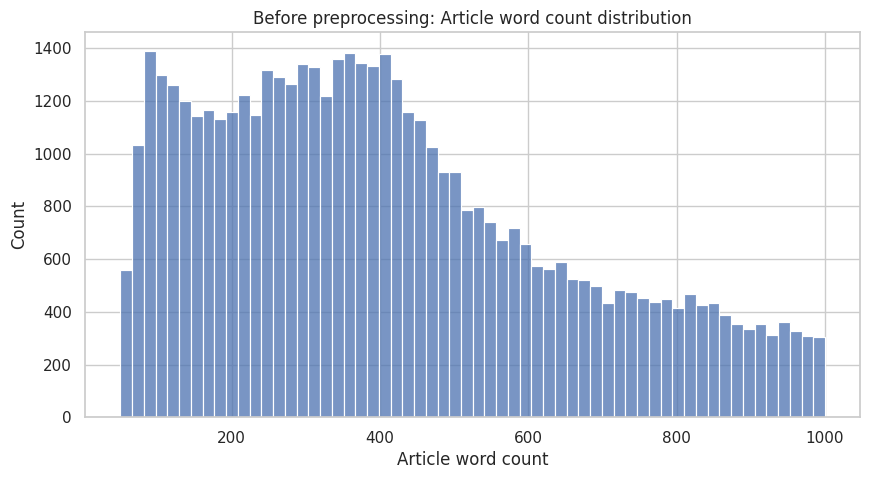

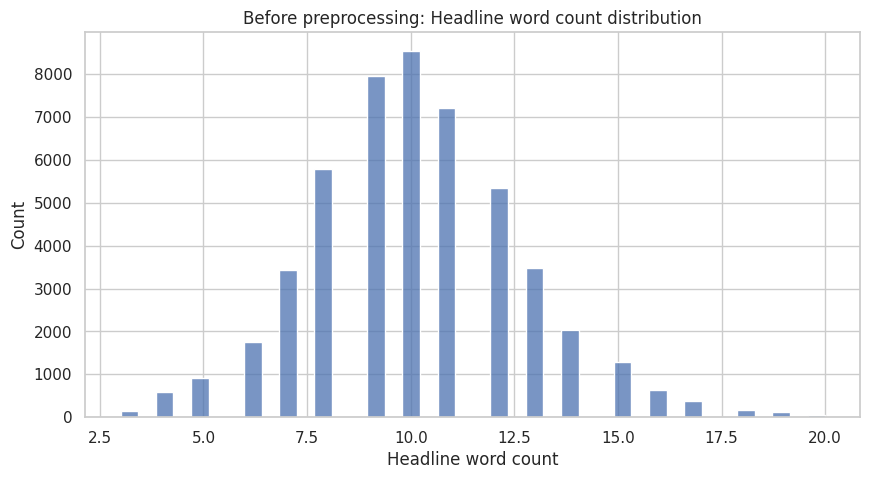

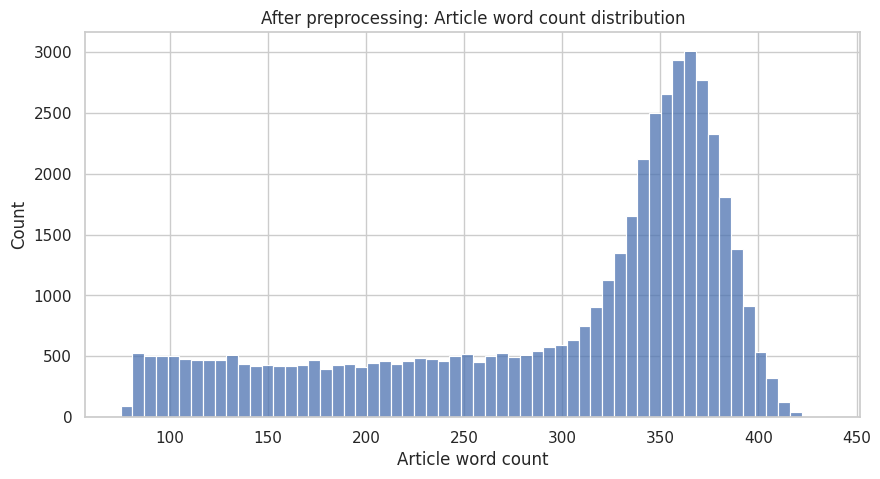

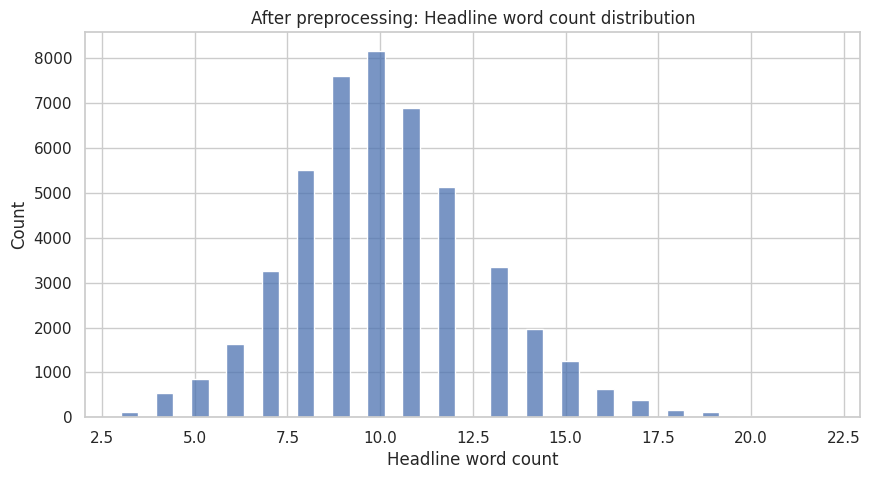

In [12]:
before_df["article_words_before"] = before_df[before_article_col].apply(word_count)
before_df["title_words_before"] = before_df[before_title_col].apply(word_count)

plot_hist(before_df["article_words_before"], "Before preprocessing: Article word count distribution", "Article word count", bins=60)
plot_hist(before_df["title_words_before"], "Before preprocessing: Headline word count distribution", "Headline word count", bins=40)

if after_df is not None:
    after_df["article_words_after"] = after_df["article_after_clean_view"].apply(word_count)
    after_df["title_words_after"] = after_df["title_after"].apply(word_count)

    plot_hist(after_df["article_words_after"], "After preprocessing: Article word count distribution", "Article word count", bins=60)
    plot_hist(after_df["title_words_after"], "After preprocessing: Headline word count distribution", "Headline word count", bins=40)

,Before article words,After article words,Before headline words,After headline words
count,49860.000000,47596.000000,49860.000000,47596.000000
mean,413.181809,296.468569,10.128119,10.148731
std,238.940361,91.278624,2.577893,2.576426
min,50.000000,75.000000,3.000000,3.000000
25%,223.000000,235.000000,8.000000,8.000000
50%,375.000000,337.000000,10.000000,10.000000
75%,565.000000,365.000000,12.000000,12.000000
max,1000.000000,434.000000,20.000000,22.000000


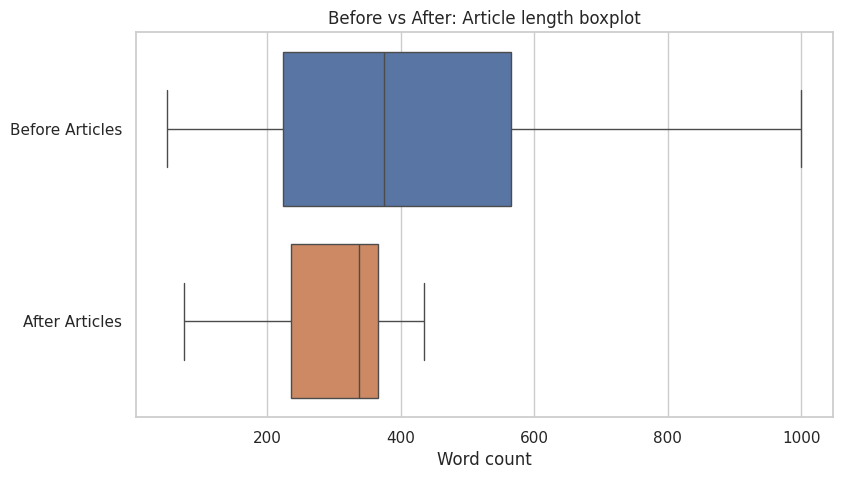

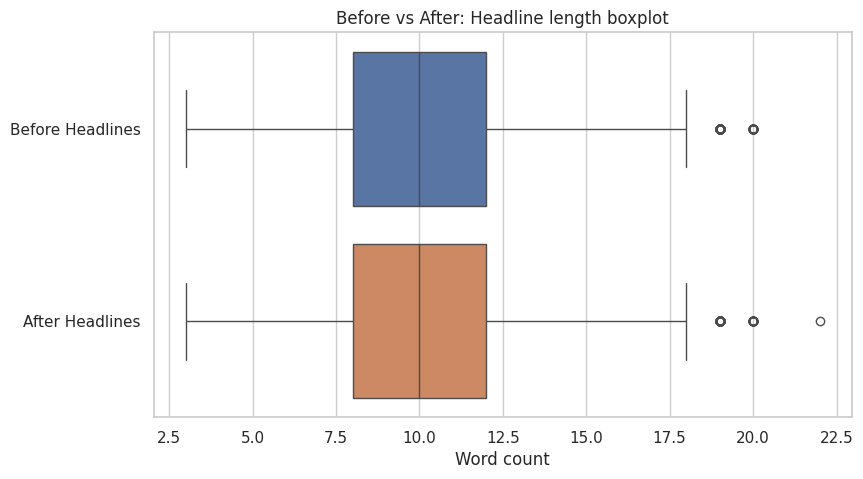

In [13]:
if after_df is not None:
    length_compare = pd.DataFrame({
        "Before article words": before_df["article_words_before"].describe(),
        "After article words": after_df["article_words_after"].describe(),
        "Before headline words": before_df["title_words_before"].describe(),
        "After headline words": after_df["title_words_after"].describe(),
    })
    display(length_compare)

    box_df = pd.DataFrame({
        "Before Articles": before_df["article_words_before"],
        "After Articles": after_df["article_words_after"],
    })
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=box_df, orient="h")
    plt.title("Before vs After: Article length boxplot")
    plt.xlabel("Word count")
    plt.show()

    box_title_df = pd.DataFrame({
        "Before Headlines": before_df["title_words_before"],
        "After Headlines": after_df["title_words_after"],
    })
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=box_title_df, orient="h")
    plt.title("Before vs After: Headline length boxplot")
    plt.xlabel("Word count")
    plt.show()

## 8. Publication and Section Distribution

This is meaningful because headline style can change by source and category.

,count
publication,
Reuters,14317
CNBC,4748
The Hill,4521
The New York Times,3738
People,3282
CNN,2598
Mashable,2236
Refinery 29,1973
Vice,1863


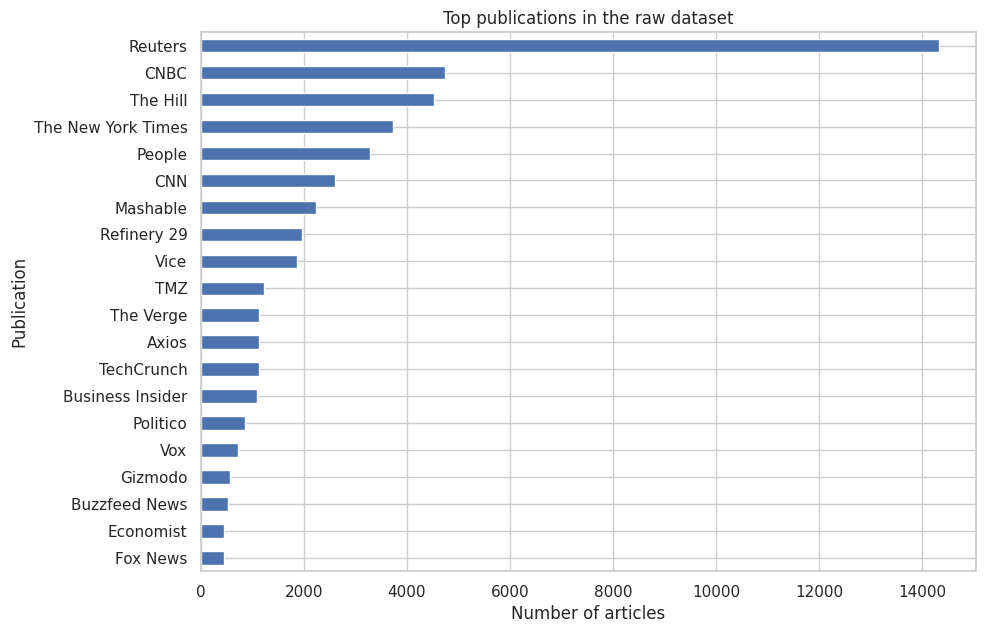

,count
section,
Unknown,17665
World News,2633
Business News,2458
politics,1048
Market News,832
us,813
Politics,802
Wires,741
Sports News,662


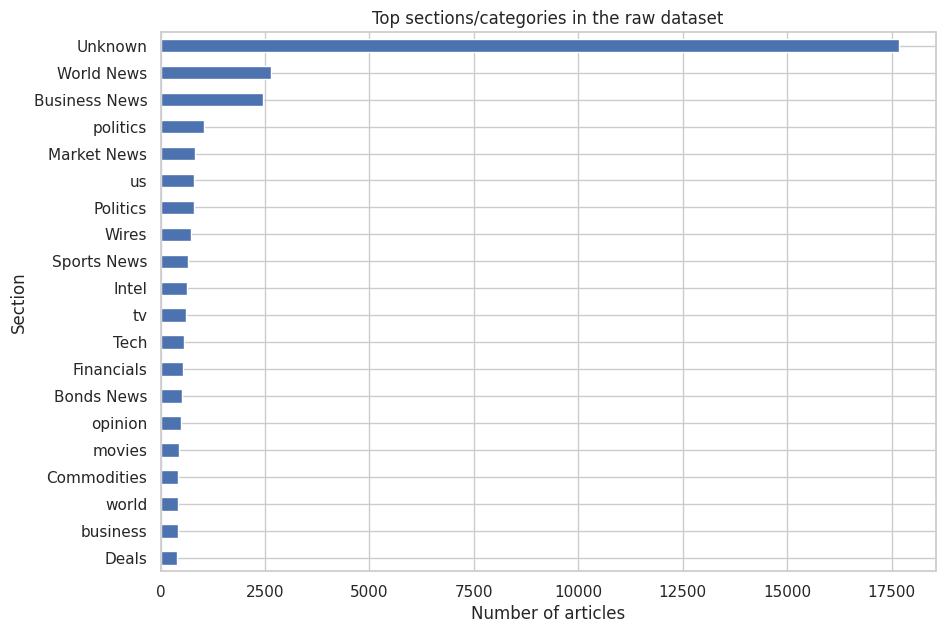

In [14]:
if "publication" in before_df.columns:
    publication_counts = before_df["publication"].fillna("Unknown").value_counts()
    display(publication_counts.head(20).to_frame("count"))
    plot_bar(publication_counts, "Top publications in the raw dataset", "Number of articles", "Publication", top_n=20)
else:
    print("No publication column found.")

if "section" in before_df.columns:
    section_counts = before_df["section"].fillna("Unknown").value_counts()
    display(section_counts.head(20).to_frame("count"))
    plot_bar(section_counts, "Top sections/categories in the raw dataset", "Number of articles", "Section", top_n=20)
else:
    print("No section column found.")

# Part B — Duplicate and Leakage Analysis

This is important because repeated or near-repeated articles can make the model memorize instead of learn.

## 9. Exact and Loose Duplicate Analysis

,Metric,Before,After
0,Exact article duplicates,0,0
1,Exact article-title pair duplicates,0,0
2,Loose near-duplicates,19,0


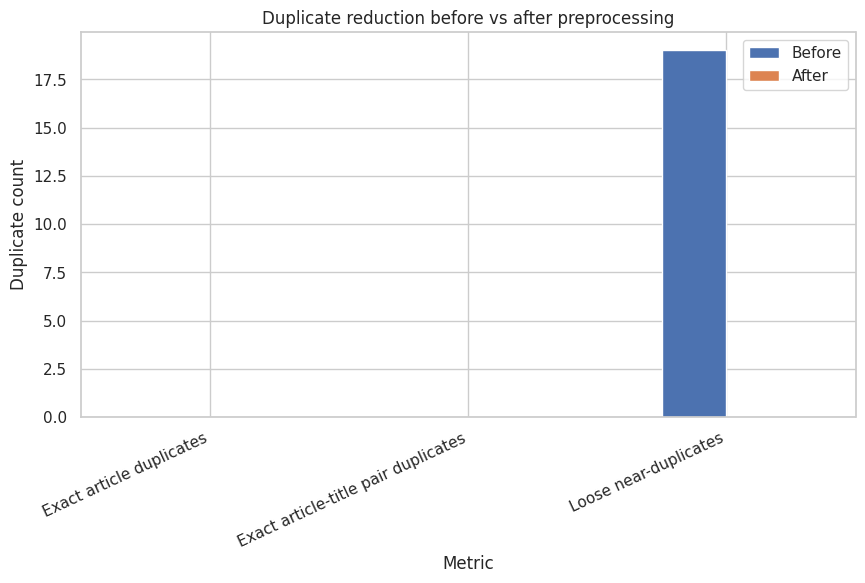

In [15]:
before_exact_article_dups = before_df[before_article_col].duplicated().sum()
before_exact_pair_dups = before_df[[before_article_col, before_title_col]].duplicated().sum()

before_df["loose_duplicate_key"] = before_df[before_article_col].apply(loose_key)
before_loose_dups = before_df["loose_duplicate_key"].duplicated().sum()

if after_df is not None:
    after_exact_article_dups = after_df["article_after_clean_view"].duplicated().sum()
    after_exact_pair_dups = after_df[["article_after_clean_view", "title_after"]].duplicated().sum()
    after_df["loose_duplicate_key"] = after_df["article_after_clean_view"].apply(loose_key)
    after_loose_dups = after_df["loose_duplicate_key"].duplicated().sum()
else:
    after_exact_article_dups = np.nan
    after_exact_pair_dups = np.nan
    after_loose_dups = np.nan

dup_summary = pd.DataFrame({
    "Metric": ["Exact article duplicates", "Exact article-title pair duplicates", "Loose near-duplicates"],
    "Before": [before_exact_article_dups, before_exact_pair_dups, before_loose_dups],
    "After": [after_exact_article_dups, after_exact_pair_dups, after_loose_dups],
})

display(dup_summary)

dup_plot = dup_summary.set_index("Metric")[["Before", "After"]]
dup_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Duplicate reduction before vs after preprocessing")
plt.ylabel("Duplicate count")
plt.xticks(rotation=25, ha="right")
plt.show()

## 10. Examples of Loose Duplicate Groups Before Preprocessing

In [16]:
loose_groups = before_df[before_df["loose_duplicate_key"].duplicated(keep=False)].copy()

if len(loose_groups) > 0:
    loose_groups["group_size"] = loose_groups.groupby("loose_duplicate_key")["loose_duplicate_key"].transform("size")
    examples = loose_groups.sort_values("group_size", ascending=False)[[before_title_col, before_article_col, "group_size"]].head(10).copy()
    examples["article_preview"] = examples[before_article_col].apply(clean_preview_text)
    display(examples[[before_title_col, "article_preview", "group_size"]])
else:
    print("No loose duplicate groups found in the raw dataset.")

,title,article_preview,group_size
3815,Nashville Stars Lennon &amp; Maisy Stella Talk Binging Riverdale &amp; the Songs They Can't Get Out of Their Head!,"It’s One Last Thing Come back every day at 8:30 a.m. EST to watch People Now streaming live from Time Inc. headquarters in New York City, and rebroadcast at...",4
42611,Actress Lake Bell Reveals Her Last Date Night: 'I'm Still Mourning',"It’s One Last Thing Come back every day at 8:30 a.m. EST to watch People Now streaming live from Time Inc. headquarters in New York City, and rebroadcast at...",4
13241,Sanaa Lathan Reveals the Last Song That Was Stuck in Her Head,"It’s One Last Thing Come back every day at 8:30 a.m. EST to watch People Now streaming live from Time Inc. headquarters in New York City, and rebroadcast at...",4
17250,RHOC's Tamra Judge Reveals Why She Googled 'Food Poisoning',"It’s One Last Thing Come back every day at 8:30 a.m. EST to watch People Now streaming live from Time Inc. headquarters in New York City, and rebroadcast at...",4
2252,"Exxon shareholders reject splitting CEO, board chair roles",May 29 (Reuters) - Exxon Mobil Corp shareholders on Wednesday rejected a proposal that would have split the roles of the chief executive and board chairman ...,2
653,"Oil rises on OPEC-led supply cuts, report of falling US crude inventories","SINGAPORE, Feb 27 (Reuters) - Oil prices rose on Wednesday after a report of declining crude inventories in the country and as producer club OPEC seemed to ...",2
646,Ex-coach of Yale women's soccer pleads guilty in admissions scandal,BOSTON (Reuters) - The former head coach of women’s soccer at Yale University admitted on Thursday that he accepted bribes to help parents get their childre...,2
4341,Slovenia PM: chance of autumn Brexit deal if Britain backs it,"SALZBURG, Austria (Reuters) - Slovenia Prime Minister Marjan Sarec said on Wednesday he believed a deal with Britain over its withdrawal from the European U...",2
8634,"Rising: February 19, 2019 | TheHill","Republican strategist Marissa Martinez predicted Monday that former Vice President Joe Biden will win the Democratic nomination, citing his fundraising prow...",2
9065,Water protests in tech hub expose urban India's growing pains,"BENGALURU (Reuters) - Oracle employees were at work on Monday when protesters entered their nine-storey building in India’s technology hub, Bengaluru, and a...",2


## 11. Train/Validation/Test Leakage Check

This checks whether the same article or loose duplicate group appears across splits.

,Comparison,Loose duplicate overlap
0,Train-Val,0
1,Train-Test,0
2,Val-Test,0


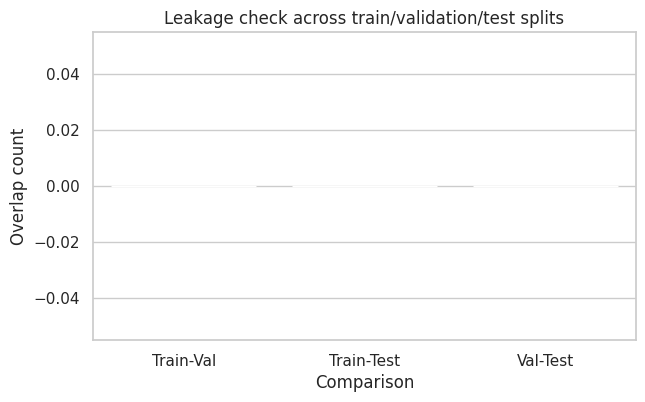

In [17]:
def read_split_if_exists(path):
    if os.path.exists(path):
        return pd.read_csv(path)
    return None

train_wide = read_split_if_exists(TRAIN_WIDE_PATH)
val_wide = read_split_if_exists(VAL_WIDE_PATH)
test_wide = read_split_if_exists(TEST_WIDE_PATH)

if train_wide is not None and val_wide is not None and test_wide is not None:
    split_article_col = get_first_existing_column(train_wide, [after_article_col] if after_df is not None else [])
    if split_article_col is None:
        split_article_col = [c for c in train_wide.columns if c.endswith("_article")][0]

    def split_keys(df):
        texts = df[split_article_col].astype(str)
        texts = texts.str.replace(r"^summarize:\s*", "", regex=True)
        texts = texts.str.replace(r"^Article:\s*", "", regex=True)
        texts = texts.str.replace(r"\nHeadline:\s*$", "", regex=True)
        return set(texts.apply(loose_key))

    train_keys = split_keys(train_wide)
    val_keys = split_keys(val_wide)
    test_keys = split_keys(test_wide)

    leakage_df = pd.DataFrame({
        "Comparison": ["Train-Val", "Train-Test", "Val-Test"],
        "Loose duplicate overlap": [
            len(train_keys & val_keys),
            len(train_keys & test_keys),
            len(val_keys & test_keys),
        ]
    })
    display(leakage_df)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=leakage_df, x="Comparison", y="Loose duplicate overlap")
    plt.title("Leakage check across train/validation/test splits")
    plt.ylabel("Overlap count")
    plt.show()
else:
    print("Split files were not found. Run preprocessing first to generate train/validation/test files.")

# Part C — Transformer Token Length Analysis

This is directly related to model training because transformers have input and target token limits.

## 12. Token Counts for T5, BART, and GPT-2

In [18]:
from transformers import AutoTokenizer

TOKENIZER_MODELS = {
    "FLAN-T5 Base": "google/flan-t5-base",
    "BART Base": "facebook/bart-base",
    "GPT-2": "gpt2",
}

MODEL_LIMITS = {
    "FLAN-T5 Base": 512,
    "BART Base": 1024,
    "GPT-2": 960,
}

TOKEN_SAMPLE_SIZE = 5000

if after_df is not None:
    token_sample = after_df.sample(min(TOKEN_SAMPLE_SIZE, len(after_df)), random_state=RANDOM_STATE).copy()
    article_texts = token_sample["article_after_clean_view"].astype(str).tolist()
    title_texts = token_sample["title_after"].astype(str).tolist()

    token_stats = []
    for model_name, tokenizer_name in TOKENIZER_MODELS.items():
        print("Tokenizing with", model_name)
        tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, use_fast=True)

        input_lengths = [len(tokenizer.encode(t, add_special_tokens=True)) for t in article_texts]
        target_lengths = [len(tokenizer.encode(t, add_special_tokens=True)) for t in title_texts]

        token_sample[f"{model_name}_input_tokens"] = input_lengths
        token_sample[f"{model_name}_target_tokens"] = target_lengths

        limit = MODEL_LIMITS[model_name]
        truncated_pct = round(np.mean(np.array(input_lengths) > limit) * 100, 2)

        token_stats.append({
            "Model": model_name,
            "Average input tokens": round(np.mean(input_lengths), 2),
            "Median input tokens": round(np.median(input_lengths), 2),
            "Average target tokens": round(np.mean(target_lengths), 2),
            "Median target tokens": round(np.median(target_lengths), 2),
            "Input limit used": limit,
            "% inputs above limit": truncated_pct,
        })

    token_stats_df = pd.DataFrame(token_stats)
    display(token_stats_df)
else:
    print("After-preprocessing dataset not loaded, so tokenizer analysis is skipped.")

Tokenizing with FLAN-T5 Base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

,Model,Average input tokens,Median input tokens,Average target tokens,Median target tokens,Input limit used,% inputs above limit
0,FLAN-T5 Base,424.47,511.0,17.08,17.0,512,0.0
1,BART Base,379.37,439.0,15.74,15.0,1024,0.0
2,GPT-2,377.37,437.0,13.74,13.0,960,0.0


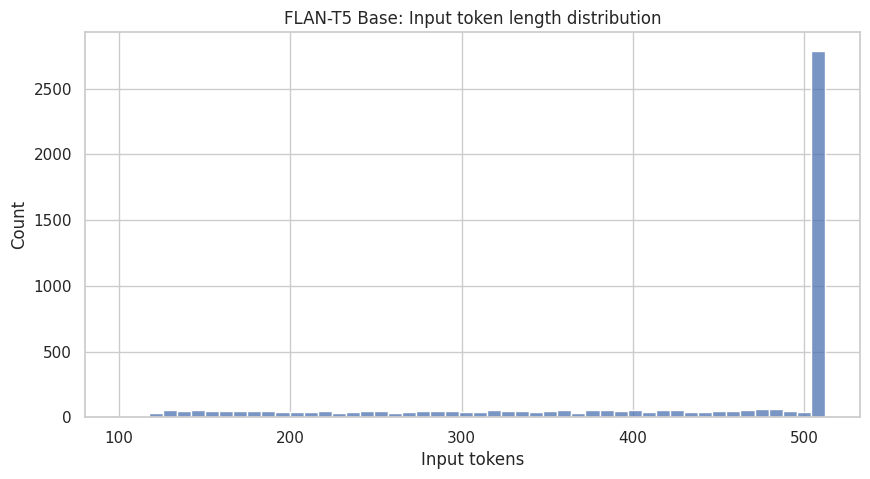

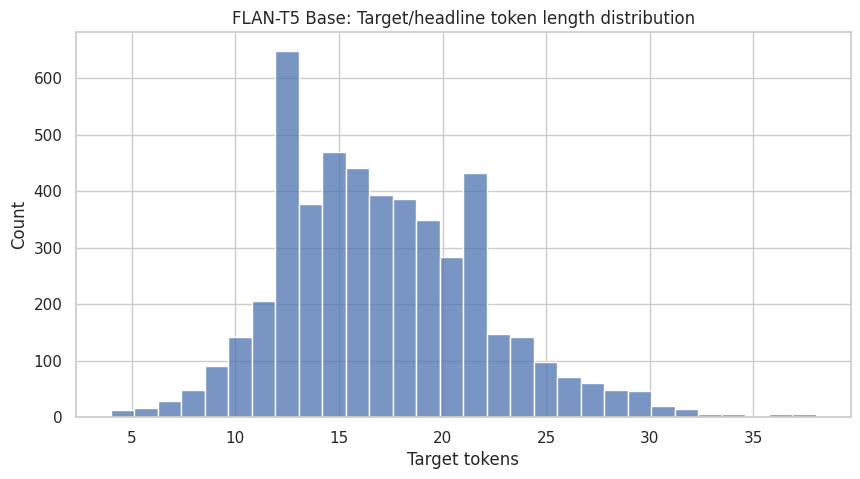

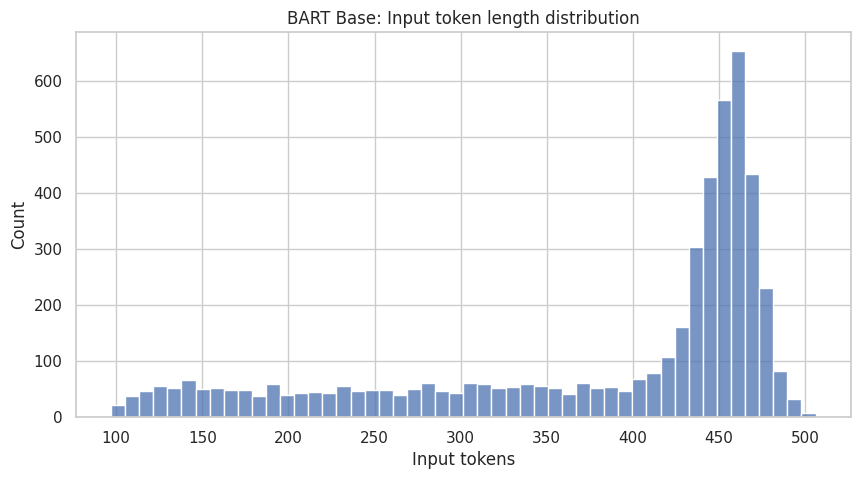

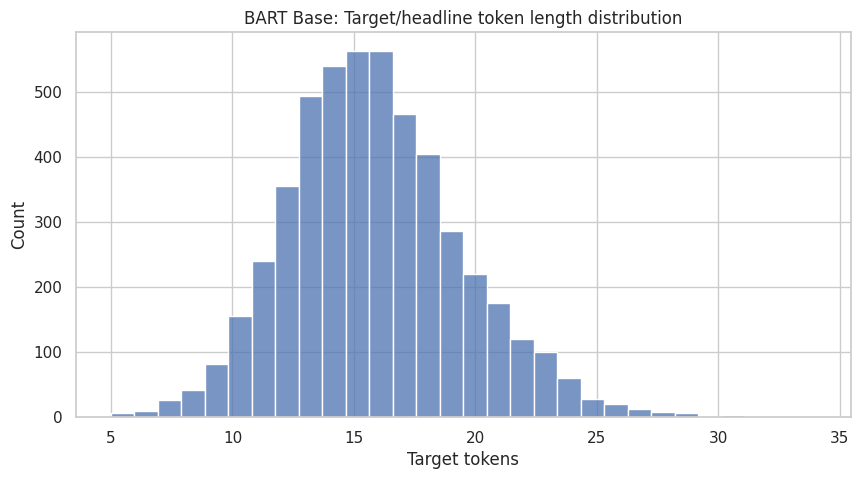

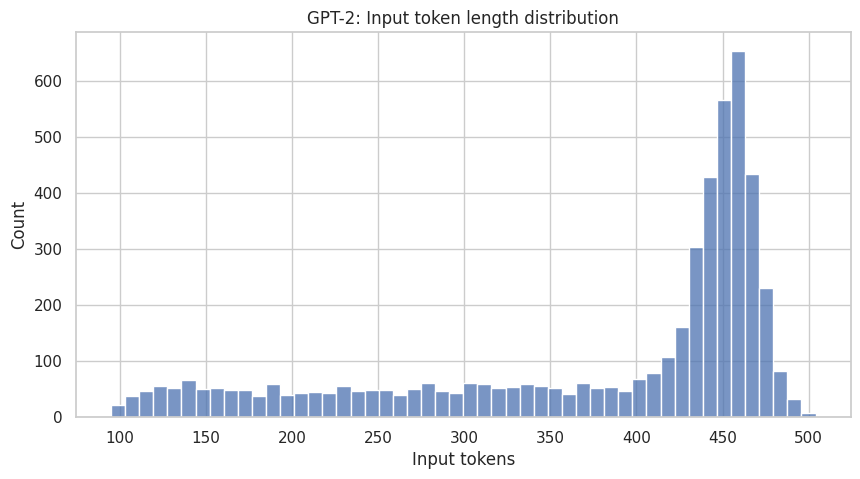

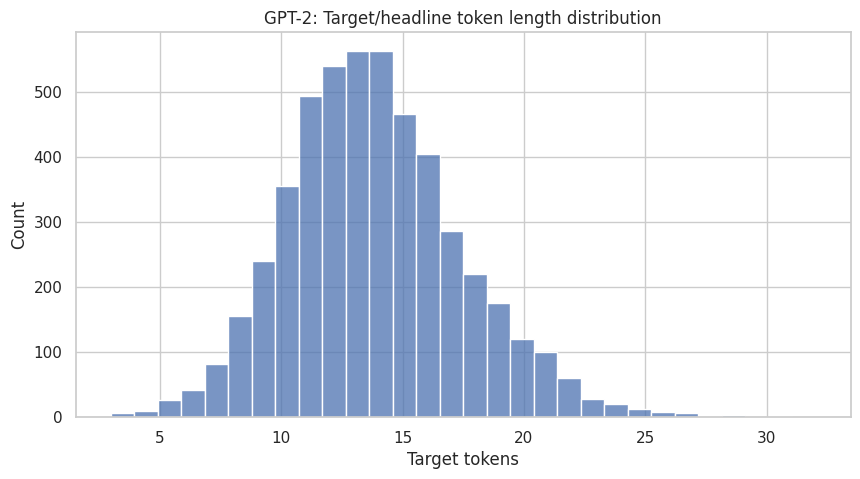

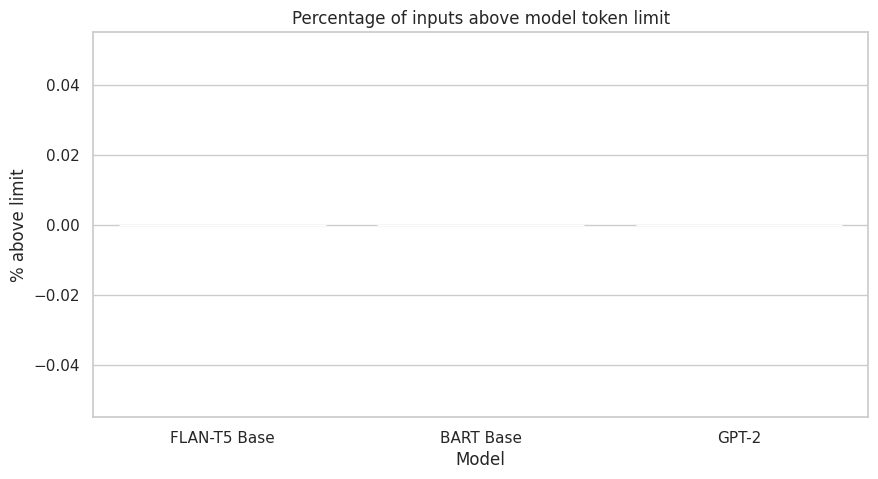

In [19]:
if after_df is not None:
    for model_name in TOKENIZER_MODELS.keys():
        plot_hist(
            token_sample[f"{model_name}_input_tokens"],
            f"{model_name}: Input token length distribution",
            "Input tokens",
            bins=50
        )
        plot_hist(
            token_sample[f"{model_name}_target_tokens"],
            f"{model_name}: Target/headline token length distribution",
            "Target tokens",
            bins=30
        )

    plt.figure(figsize=(10, 5))
    sns.barplot(data=token_stats_df, x="Model", y="% inputs above limit")
    plt.title("Percentage of inputs above model token limit")
    plt.ylabel("% above limit")
    plt.show()

# Part D — Semantic Similarity Analysis

This checks whether the headline and article are semantically related.  
It is stronger than lexical overlap because it compares meaning, not only shared words.

## 13. Article-Headline Semantic Similarity

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

,semantic_similarity
count,3000.000000
mean,0.635649
std,0.118886
min,0.003216
25%,0.576658
50%,0.652083
75%,0.718559
max,0.893840


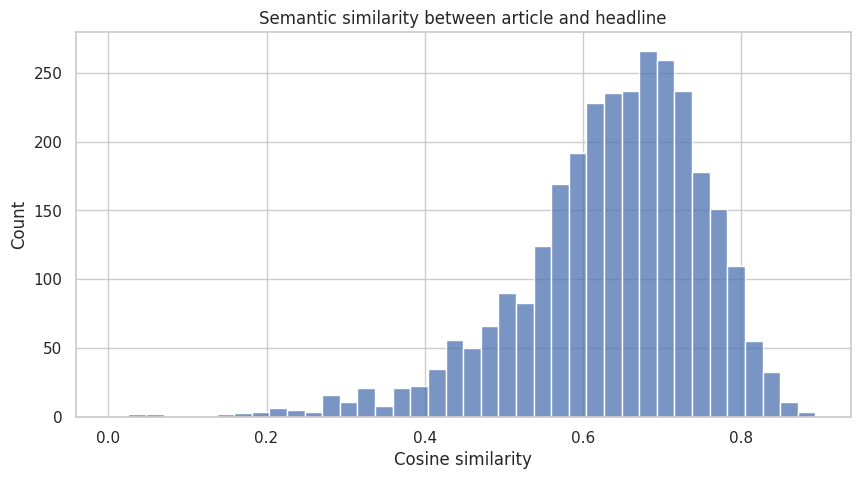

In [20]:
SEMANTIC_SAMPLE_SIZE = 3000

if after_df is not None:
    from sentence_transformers import SentenceTransformer, util

    semantic_sample = after_df.sample(min(SEMANTIC_SAMPLE_SIZE, len(after_df)), random_state=RANDOM_STATE).copy()
    semantic_model = SentenceTransformer("all-MiniLM-L6-v2")

    # Use the first part of the article because full articles can be very long.
    article_texts = semantic_sample["article_after_clean_view"].astype(str).str[:1500].tolist()
    title_texts = semantic_sample["title_after"].astype(str).tolist()

    title_emb = semantic_model.encode(title_texts, convert_to_tensor=True, show_progress_bar=True, batch_size=64)
    article_emb = semantic_model.encode(article_texts, convert_to_tensor=True, show_progress_bar=True, batch_size=64)

    semantic_sample["semantic_similarity"] = util.cos_sim(title_emb, article_emb).diagonal().cpu().numpy()

    display(semantic_sample["semantic_similarity"].describe().to_frame("semantic_similarity"))

    plot_hist(
        semantic_sample["semantic_similarity"],
        "Semantic similarity between article and headline",
        "Cosine similarity",
        bins=40
    )
else:
    print("After-preprocessing dataset not loaded, so semantic similarity analysis is skipped.")

In [21]:
if after_df is not None:
    print("Lowest semantic similarity examples")
    low_examples = semantic_sample.sort_values("semantic_similarity").head(8).copy()
    low_examples["article_preview"] = low_examples["article_after_clean_view"].apply(clean_preview_text)
    display(low_examples[["title_after", "article_preview", "semantic_similarity"]])

    print("Highest semantic similarity examples")
    high_examples = semantic_sample.sort_values("semantic_similarity", ascending=False).head(8).copy()
    high_examples["article_preview"] = high_examples["article_after_clean_view"].apply(clean_preview_text)
    display(high_examples[["title_after", "article_preview", "semantic_similarity"]])

Lowest semantic similarity examples


,title_after,article_preview,semantic_similarity
48912,Will Minority Report cybergloves ever make sense?,"Senso is an experimental glove peripheral that tracks individual fingers for virtual reality hand controls, while offering haptic feedback that includes vib...",0.003216
12310,"Corrections: February 9, 2019","ARTS A theater entry in the Listings pages on Friday misstated the phone number for ticket information regarding the play ""'Daddy.'"" It is 212-279-4200, not...",0.028672
9798,The Line Tamers,I learned everything I needed to know about Super Bowl 50 on Twitter. I saw people turning up eight days before the game to voluntarily enter a Verizon-spon...,0.041820
18989,Gridlock Central - Lexington,"AMERICANS dismayed by the 2016 elections should brace themselves: next year political divisions will probably deepen. With a hot-headed, thin-skinned Presid...",0.060596
13689,Inside the List,"Election Fever Dream: If Hillary Clinton did not exist, conservative writers would have to invent her - if, that is, they wanted to continue churning out be...",0.069545
4412,"10 things in tech you need to know today, August 9",Good morning! This is the tech news you need to know this Friday.Uber on Thursday reported second-quarter earnings that widely missed Wall Street expectatio...,0.131645
29638,Business this week,"The Chinese government expressed confidence that it could reach a trade agreement with America by March 1st, following Donald Trump's undertaking to postpon...",0.155871
24084,"Quickly catch up: Thursday, July 20",(CNN)Here's what you might have missed on CNN today: O.J. SIMPSON GRANTED PAROLE -- O.J. Simpson has been granted parole after serving nine years of his nin...,0.157044


Highest semantic similarity examples


,title_after,article_preview,semantic_similarity
15613,Britain's CDC acquires 5% stake in Morocco's BMCE Bank of Africa,"RABAT, June 19 (Reuters) - British development finance agency CDC Group acquired nearly 5% stake in Morocco's BMCE Bank of Africa after a $200 million capit...",0.893840
1537,Indonesia to ban face mask exports to ensure domestic supply,"JAKARTA, March 13 (Reuters) - Indonesia will temporarily ban the export of face masks to safeguard domestic supply amid the coronavirus outbreak, Trade Mini...",0.891919
23154,Malaysia's Petronas to take 25 percent stake in LNG Canada,Malaysia's Petronas said on Thursday it had agreed to buy a 25 percent stake in the LNG Canada project. Petronas will buy the equity stake in the project in...,0.876649
36311,Gazprom says to make bulk of gas discount deal payments to Turkey soon,"Russian gas giant Gazprom will make the bulk of payments to Turkey as part of a gas discount deal in the near future, a company official said on Wednesday. ...",0.874976
4310,Howard Stern: I've Never Heard 'Locker Room Talk' Like Trump's,"Radio host Howard Stern said he has never heard ""locker room talk"" of the sort Donald Trump claimed he engaged in after a 2005 video leaked showing the GOP ...",0.869346
22116,Saudi Arabia launches special residency scheme for expats,"Saudi Arabia launched on Sunday their new special residency scheme similar to green card systems applicable in other countries, aimed at attracting wealthy ...",0.868288
15799,Uber launches boat service in Nigeria's megacity Lagos,* Lagos boat service pilot test to last two weeks * Uber partnering with local boat firm and Lagos state government * Transport firms targeting new users in...,0.866742
15552,China's Alibaba aims to double Tmall Global brands with English portal,"(Corrects Tmall throughout to Tmall Global) SHANGHAI, June 26 (Reuters) - Chinese e-commerce giant Alibaba on Wednesday launched an English-language website...",0.862494


# Part E — Headline N-Gram Analysis

This shows common headline patterns that the model may learn.

## 14. Most Common Headline Bigrams and Trigrams

In [22]:
def get_top_ngrams(texts, ngram_range=(2, 2), top_n=25):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        stop_words="english",
        min_df=2,
        max_features=5000
    )
    X = vectorizer.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    ngram_df = pd.DataFrame({"ngram": terms, "count": counts})
    return ngram_df.sort_values("count", ascending=False).head(top_n)

if after_df is not None:
    headline_texts = after_df["title_after"].astype(str).tolist()
else:
    headline_texts = before_df[before_title_col].astype(str).tolist()

bigram_df = get_top_ngrams(headline_texts, ngram_range=(2, 2), top_n=25)
trigram_df = get_top_ngrams(headline_texts, ngram_range=(3, 3), top_n=25)

display(bigram_df)
display(trigram_df)

,ngram,count
1258,donald trump,350
3000,new york,332
4906,white house,329
3047,north korea,231
3510,report thehill,197
1979,hong kong,176
4265,supreme court,155
4849,wall street,140
4655,trump says,134
4972,year old,133


,ngram,count
2656,new york city,50
3784,stocks wall st,48
592,canada stocks tsx,41
3483,self driving cars,38
2677,new york times,37
1544,global markets stocks,28
3774,stocks making biggest,26
1074,draft political news,26
726,china trade war,26
2318,making biggest moves,25


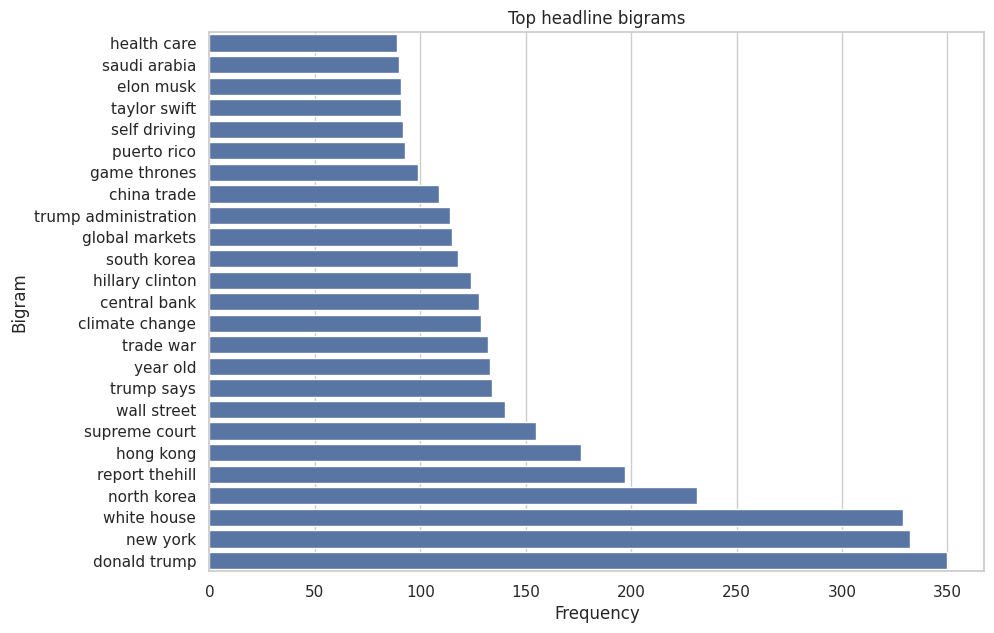

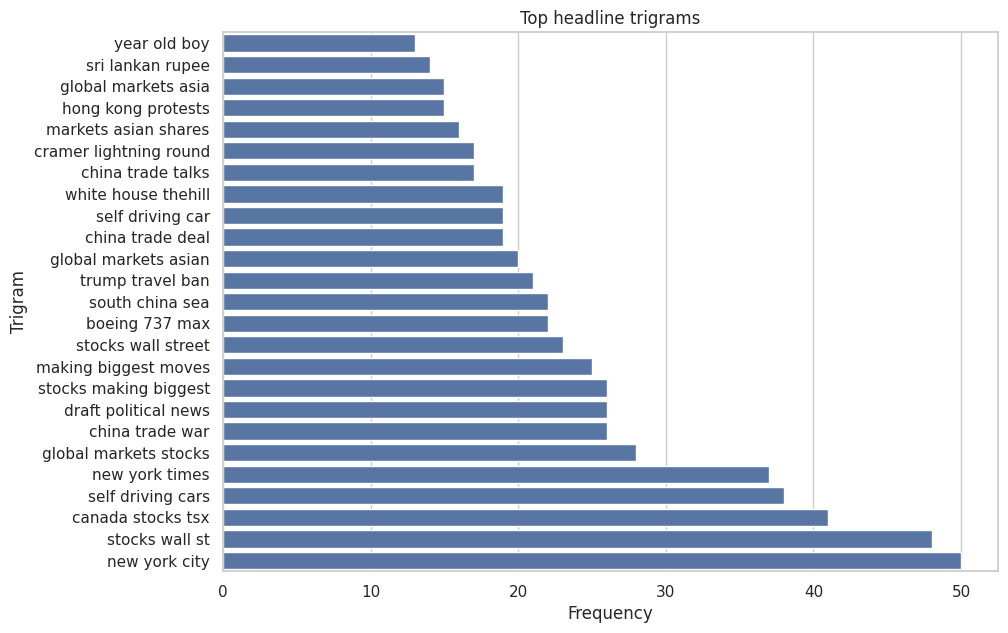

In [23]:
plt.figure(figsize=(10, 7))
sns.barplot(data=bigram_df.sort_values("count"), x="count", y="ngram")
plt.title("Top headline bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()

plt.figure(figsize=(10, 7))
sns.barplot(data=trigram_df.sort_values("count"), x="count", y="ngram")
plt.title("Top headline trigrams")
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.show()

# Part F — Named Entity Analysis in Headlines

News headlines often depend on people, organizations, and locations.  
This section checks which entity types are common in the target headlines.

## 15. Entity Type Distribution and Top Entities

In [24]:
NER_SAMPLE_SIZE = 5000

try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
    HAS_SPACY = True
except Exception as e:
    HAS_SPACY = False
    print("spaCy model was not loaded:", e)

if HAS_SPACY:
    if after_df is not None:
        ner_texts = after_df["title_after"].astype(str).sample(min(NER_SAMPLE_SIZE, len(after_df)), random_state=RANDOM_STATE).tolist()
    else:
        ner_texts = before_df[before_title_col].astype(str).sample(min(NER_SAMPLE_SIZE, len(before_df)), random_state=RANDOM_STATE).tolist()

    entity_rows = []
    for doc in nlp.pipe(ner_texts, batch_size=64):
        for ent in doc.ents:
            entity_rows.append({"entity": ent.text, "label": ent.label_})

    entity_df = pd.DataFrame(entity_rows)
    print("Number of extracted headline entities:", len(entity_df))
    display(entity_df.head(10))
else:
    entity_df = pd.DataFrame()

Number of extracted headline entities: 9060


,entity,label
0,second,ORDINAL
1,Australian,NORP
2,a week,DATE
3,Eat Lab-Grown Meat,ORG
4,2040,DATE
5,DP World,ORG
6,Djibouti,GPE
7,Kim Kardashian Listens,PERSON
8,Taylor Swift's,PERSON
9,Music After Ending Feud,ORG


,count
label,
ORG,3072
PERSON,1965
GPE,1705
DATE,575
NORP,519
CARDINAL,462
MONEY,182
WORK_OF_ART,118
ORDINAL,108


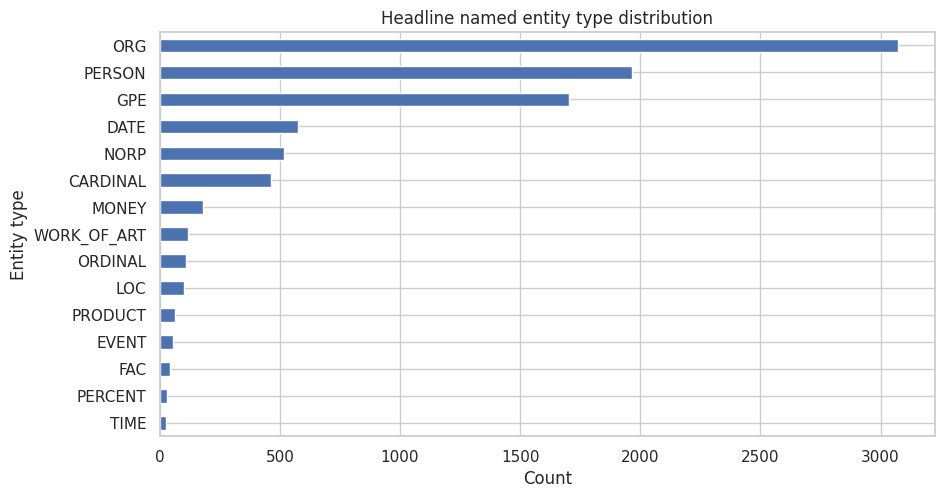

,Top PERSON entities
entity,
Trump,65
Brexit,39
Clinton,34
Donald Trump,32
Obama,21
Twitter,13
Hillary Clinton,10
Putin,9
McCain,8


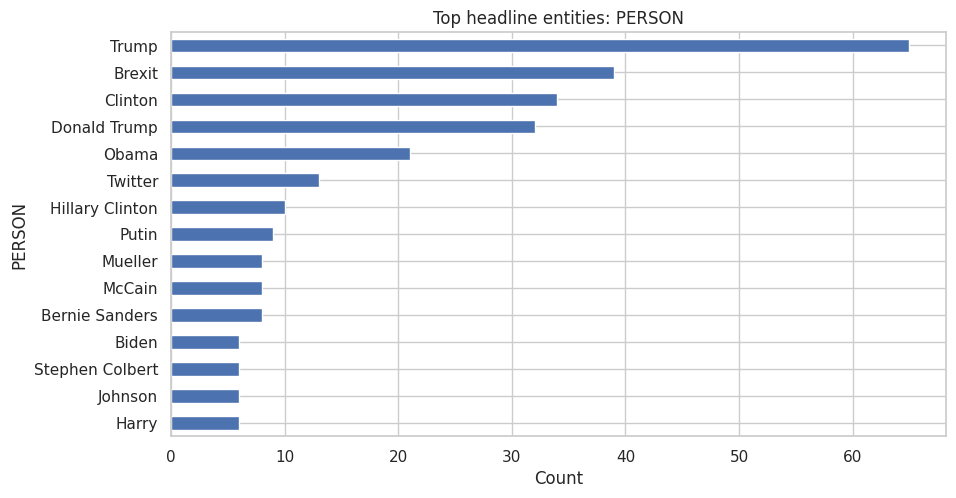

,Top ORG entities
entity,
TheHill,497
Trump,170
GOP,48
EU,41
Amazon,40
House,36
Senate,30
Apple,27
Google,26


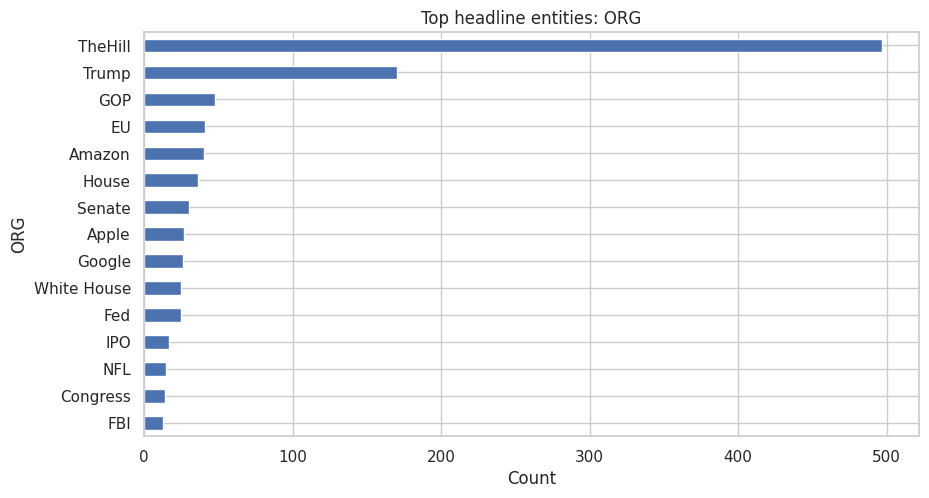

,Top GPE entities
entity,
U.S.,182
China,95
US,77
UK,59
Russia,51
India,39
Brazil,33
Iran,32
Syria,29


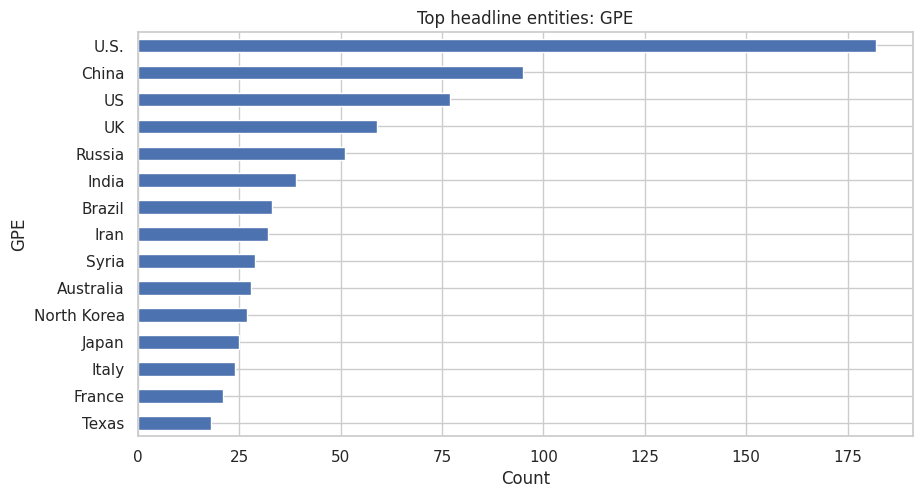

In [25]:
if len(entity_df) > 0:
    entity_type_counts = entity_df["label"].value_counts()
    display(entity_type_counts.to_frame("count"))
    plot_bar(entity_type_counts, "Headline named entity type distribution", "Count", "Entity type", top_n=15)

    for label in ["PERSON", "ORG", "GPE"]:
        top_entities = entity_df[entity_df["label"] == label]["entity"].value_counts().head(15)
        if len(top_entities) > 0:
            display(top_entities.to_frame(f"Top {label} entities"))
            plot_bar(top_entities, f"Top headline entities: {label}", "Count", label, top_n=15)
else:
    print("No entities were extracted.")

# Part G — Final Dashboard Summary

This final table is useful for your report or presentation.

## 16. Final Before vs After Dashboard

In [26]:
dashboard_rows = []

def add_metric(metric, before_value, after_value=None):
    dashboard_rows.append({"Metric": metric, "Before": before_value, "After": after_value})

add_metric("Rows", len(before_df), len(after_df) if after_df is not None else np.nan)
add_metric("Exact article duplicates", before_exact_article_dups, after_exact_article_dups)
add_metric("Loose near-duplicates", before_loose_dups, after_loose_dups)
add_metric("Average article words", round(before_df["article_words_before"].mean(), 2), round(after_df["article_words_after"].mean(), 2) if after_df is not None else np.nan)
add_metric("Average headline words", round(before_df["title_words_before"].mean(), 2), round(after_df["title_words_after"].mean(), 2) if after_df is not None else np.nan)

if after_df is not None and "token_stats_df" in globals():
    for _, row in token_stats_df.iterrows():
        add_metric(f"{row['Model']} avg input tokens", np.nan, row["Average input tokens"])
        add_metric(f"{row['Model']} % inputs above limit", np.nan, row["% inputs above limit"])

if after_df is not None and "semantic_sample" in globals() and "semantic_similarity" in semantic_sample.columns:
    add_metric("Average semantic similarity", np.nan, round(semantic_sample["semantic_similarity"].mean(), 3))

final_dashboard_df = pd.DataFrame(dashboard_rows)
display(final_dashboard_df)

,Metric,Before,After
0,Rows,49860.00,47596.000
1,Exact article duplicates,0.00,0.000
2,Loose near-duplicates,19.00,0.000
3,Average article words,413.18,296.470
4,Average headline words,10.13,10.150
5,FLAN-T5 Base avg input tokens,NaN,424.470
6,FLAN-T5 Base % inputs above limit,NaN,0.000
7,BART Base avg input tokens,NaN,379.370
8,BART Base % inputs above limit,NaN,0.000
9,GPT-2 avg input tokens,NaN,377.370


In [27]:
# Save the dashboard table so it can be used in your report.
ANALYSIS_OUTPUT_DIR = os.path.join(PREPROCESSED_DIR, "analysis_outputs")
os.makedirs(ANALYSIS_OUTPUT_DIR, exist_ok=True)

dashboard_path = os.path.join(ANALYSIS_OUTPUT_DIR, "before_after_analysis_dashboard.csv")
final_dashboard_df.to_csv(dashboard_path, index=False)
print("Saved dashboard to:", dashboard_path)

Saved dashboard to: /content/drive/MyDrive/headlineGenerationProjectNLP/news_headline_model_data/analysis_outputs/before_after_analysis_dashboard.csv
